[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tqb634/LVTN/blob/master/main_simulation.ipynb)

# IM-DD Optical Access Link — Trade-off Study
**OOK vs 4-PAM under varying received power, receiver bandwidth, fiber length, and dispersion**

This notebook runs all simulations and produces all figures for the thesis.
All signal processing logic lives in `imdd_lib.py` — this file only sets parameters and calls functions.

---
**Structure**
1. Setup
2. Global simulation parameters
3. Single-run sanity check + eye diagrams
4. Sweep 1 — BER vs Received Power (OOK vs PAM4)
5. Sweep 2 — BER vs Receiver Bandwidth (OOK vs PAM4)
6. Sweep 3 — BER vs Fiber Length (OOK vs PAM4)
7. Sweep 4 — BER vs Fiber Dispersion (OOK vs PAM4)
8. Trade-off summary table

---
## 1. Setup

In [2]:
# Install OptiCommPy if running on Google Colab
if 'google.colab' in str(get_ipython()):
    ! git clone -b main https://github.com/edsonportosilva/OptiCommPy
    from os import chdir as cd
    cd('/content/OptiCommPy/')
    ! pip install .

    cd('/content/')
    ! git clone https://github.com/tqb634/LVTN.git
    cd('/content/LVTN/')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.core.pylabtools import figsize
from IPython.core.display import HTML

from imdd_lib import (
    run_link,
    plot_eye_diagrams,
    plot_ber_vs_power,
    plot_ber_vs_bandwidth,
    plot_ber_vs_length,
    plot_ber_vs_dispersion,
    print_summary,
    sweep_param,
)

figsize(10, 3)
HTML("""
<style>
.output_png { display: table-cell; text-align: center; vertical-align: middle; }
</style>
""")

---
## 2. Global Simulation Parameters

All shared parameters are defined here.  
Sweep-specific overrides are set locally in each sweep section.

In [4]:
# ── Simulation resolution ────────────────────────────────────────────────────
SpS    = 16            # samples per symbol
nBits  = 100_000   # bits per simulation run

# ── Signal parameters ────────────────────────────────────────────────────────
Rs_OOK  = 10e9      # symbol rate [Hz]
Rs_4PAM = 5e9

# ── Fiber parameters (defaults — overridden per sweep) ───────────────────────
FIBER_L     = 10   # fiber length [km]
FIBER_ALPHA = 0.2  # attenuation [dB/km]
FIBER_D     = 16   # dispersion  [ps/nm/km]
Fc          = 193.1e12  # central optical frequency [Hz]

# ── Receiver parameters (defaults) ───────────────────────────────────────────
RX_BW_OOK = Rs_OOK         # matched-filter bandwidth (B = Rs)
RX_BW_4PAM = Rs_4PAM

# ── BER target reference line ────────────────────────────────────────────────
BER_TARGET = 1e-3  # choose FEC threshold for access links

print(f"Symbol rate OOK   : {Rs_OOK/1e9:.0f} Gbaud")
print(f"Symbol rate 4-PAM : {Rs_4PAM/1e9:.0f} Gbaud")
print(f"Bit rate OOK      : {Rs_OOK/1e9:.0f} Gb/s")
print(f"Bit rate PAM4     : {2*Rs_4PAM/1e9:.0f} Gb/s")
print(f"Fiber             : {FIBER_L} km, α={FIBER_ALPHA} dB/km, D={FIBER_D} ps/nm/km")

Symbol rate OOK   : 10 Gbaud
Symbol rate 4-PAM : 5 Gbaud
Bit rate OOK      : 10 Gb/s
Bit rate PAM4     : 10 Gb/s
Fiber             : 10 km, α=0.2 dB/km, D=16 ps/nm/km


---
## 3. Sweep 1 — BER vs Received Power

**Fixed:** fiber length, receiver bandwidth

**Swept:** lase input power `Pi_dBm` -> transmit power -> received power after fiber loss

**Goal:** find the power penalty of PAM4 vs OOK at BER = 10⁻³

**3.1 10Gb/s over 10km**

Sweep: Pi_dBm: 100%|██████████| 40/40 [00:37<00:00,  1.08it/s]
C:\Users\Admin\PycharmProjects\JupyterProject\imdd_lib.py:534: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


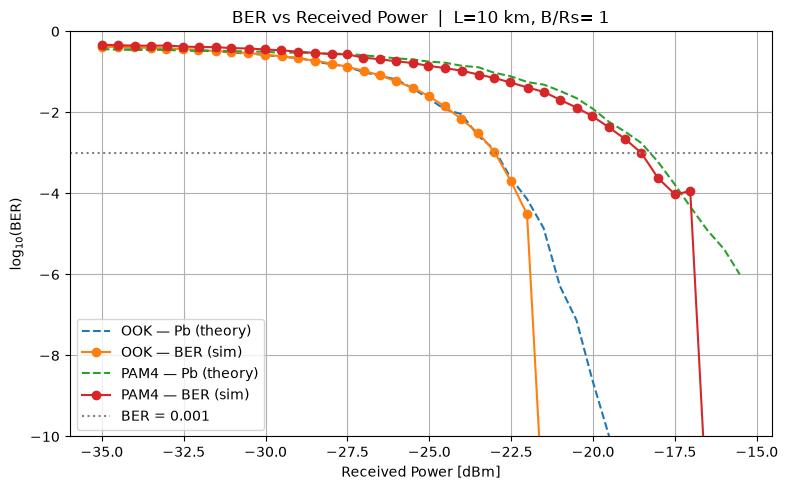

In [5]:
bit_rate = 10e9        # Gb/s
Rs_OOK_31  = bit_rate     # symbol rate [Hz]
Rs_4PAM_31 = bit_rate/2

RX_BW_OOK_31 = Rs_OOK_31         # matched-filter bandwidth (B = Rs)
RX_BW_4PAM_31 = Rs_4PAM_31

power_range = np.arange(-30, -10, 0.5)  # [dBm]

sweep1_ook = sweep_param(
    param_name   = 'Pi_dBm',
    param_range  = power_range,
    fixed_params = {
        'M': 2,
        'Rs': Rs_OOK_31,
        'SpS': SpS,
        'fiber_L': FIBER_L,
        'fiber_alpha': FIBER_ALPHA,
        'fiber_D': FIBER_D,
        'Fc': Fc,
        'rx_bandwidth': RX_BW_OOK_31,
        'nBits': nBits,
    }
)

sweep1_pam4 = sweep_param(
    param_name   = 'Pi_dBm',
    param_range  = power_range,
    fixed_params = {
        'M': 4,
        'Rs': Rs_4PAM_31,
        'SpS': SpS,
        'fiber_L': FIBER_L,
        'fiber_alpha': FIBER_ALPHA,
        'fiber_D': FIBER_D,
        'Fc': Fc,
        'rx_bandwidth': RX_BW_4PAM_31,
        'nBits': nBits,
    }
)

plot_ber_vs_power(
    results_list = [sweep1_ook, sweep1_pam4],
    labels       = ['OOK', 'PAM4'],
    title        = f'BER vs Received Power  |  L={FIBER_L} km, B/Rs= 1',
    target_BER   = BER_TARGET,
)

**3.2 40Gb/s over 10km**

Sweep: Pi_dBm: 100%|██████████| 25/25 [00:23<00:00,  1.08it/s]


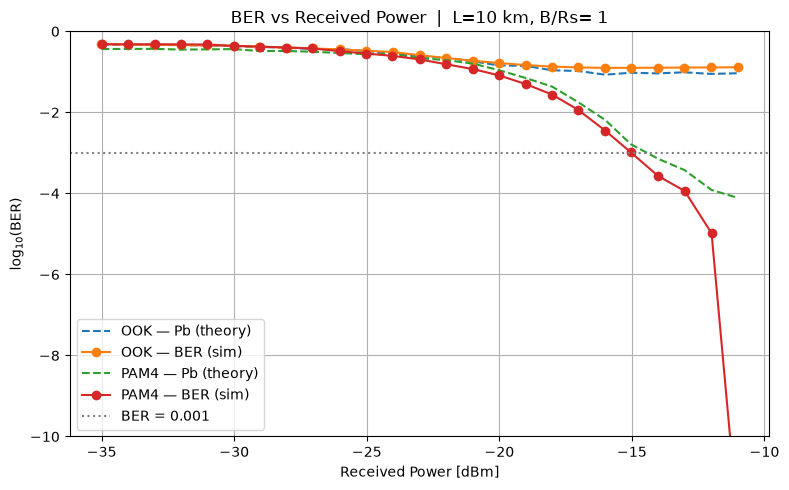

In [6]:
bit_rate = 40e9        # Gb/s
Rs_OOK_32  = bit_rate     # symbol rate [Hz]
Rs_4PAM_32 = bit_rate/2

RX_BW_OOK_32 = Rs_OOK_32         # matched-filter bandwidth (B = Rs)
RX_BW_4PAM_32 = Rs_4PAM_32

FIBER_L = 10           # fiber length [km]

power_range = np.arange(-30, -5, 1)  # [dBm]

sweep1_ook = sweep_param(
    param_name   = 'Pi_dBm',
    param_range  = power_range,
    fixed_params = {
        'M': 2,
        'Rs': Rs_OOK_32,
        'SpS': SpS,
        'fiber_L': FIBER_L,
        'fiber_alpha': FIBER_ALPHA,
        'fiber_D': FIBER_D,
        'Fc': Fc,
        'rx_bandwidth': RX_BW_OOK_32,
        'nBits': nBits,
    }
)

sweep1_pam4 = sweep_param(
    param_name   = 'Pi_dBm',
    param_range  = power_range,
    fixed_params = {
        'M': 4,
        'Rs': Rs_4PAM_32,
        'SpS': SpS,
        'fiber_L': FIBER_L,
        'fiber_alpha': FIBER_ALPHA,
        'fiber_D': FIBER_D,
        'Fc': Fc,
        'rx_bandwidth': RX_BW_4PAM_32,
        'nBits': nBits,
    }
)

plot_ber_vs_power(
    results_list = [sweep1_ook, sweep1_pam4],
    labels       = ['OOK', 'PAM4'],
    title        = f'BER vs Received Power  |  L={FIBER_L} km, B/Rs= 1',
    target_BER   = BER_TARGET,
)

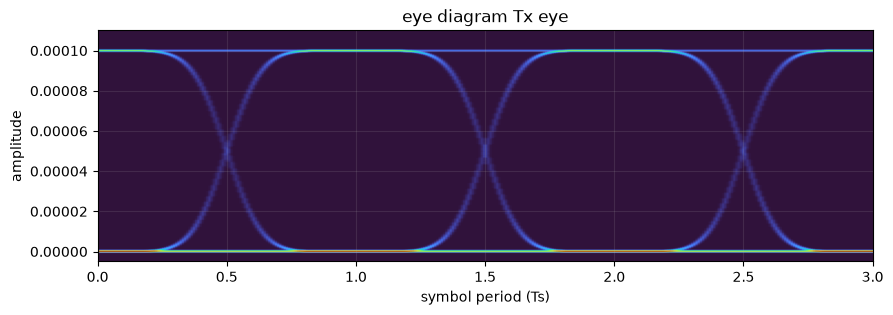

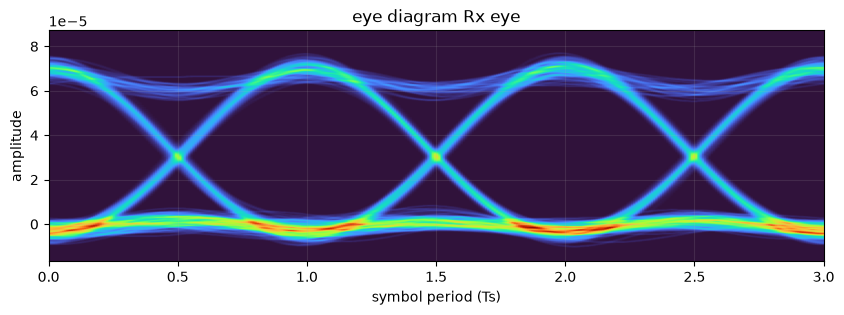

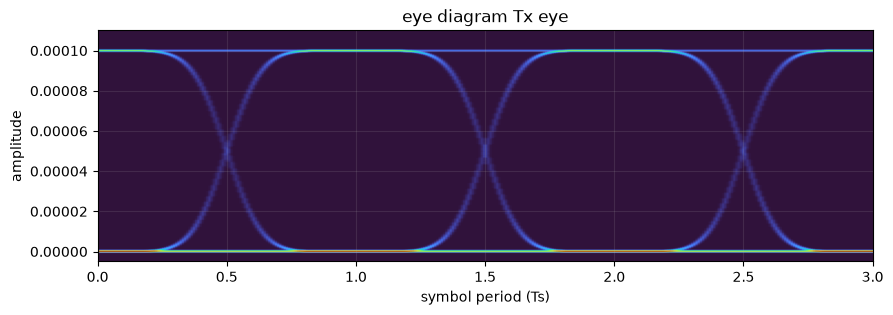

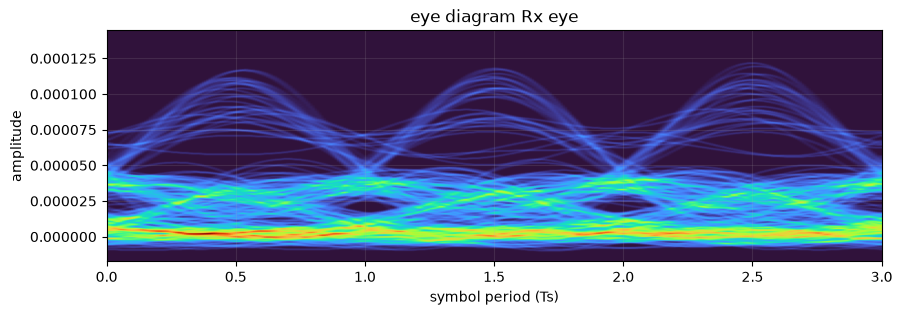

In [44]:
res = run_link(Pi_dBm=-10, M=2, Rs=10e9, fiber_L=10)
plot_eye_diagrams(res, discard=50)

res = run_link(Pi_dBm=-10, M=2, Rs=40e9, fiber_L=10)
plot_eye_diagrams(res, discard=50)

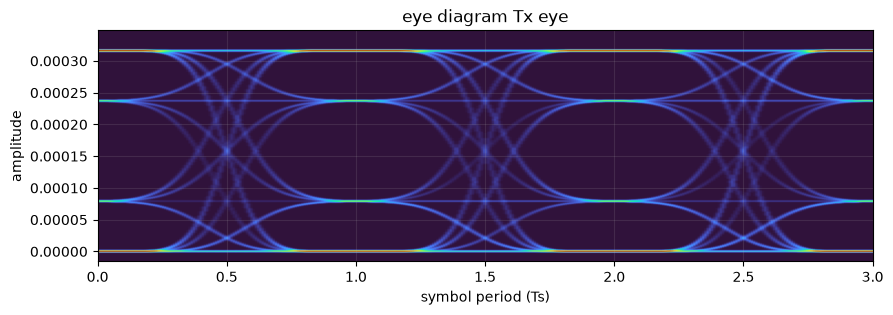

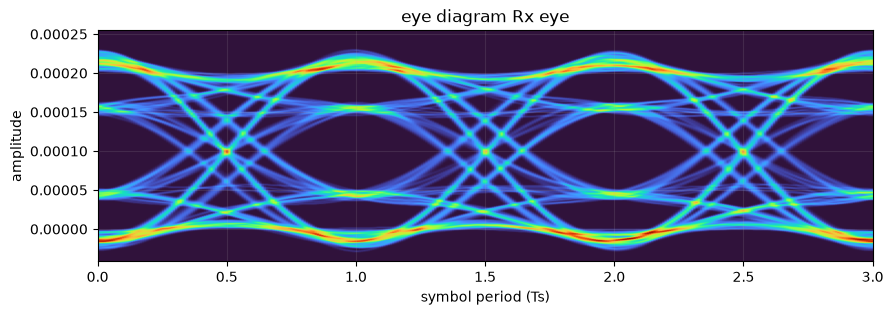

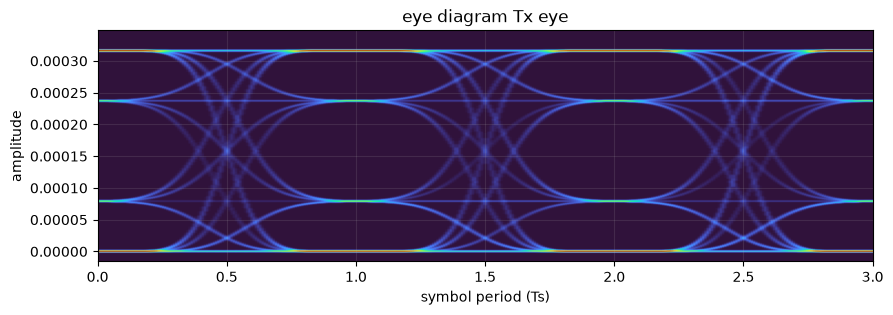

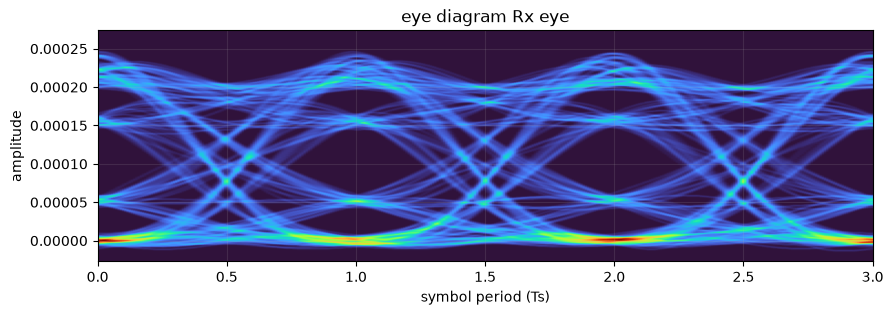

In [43]:
res = run_link(Pi_dBm=-10, M=4, Rs=5e9, fiber_L=10)
plot_eye_diagrams(res, discard=50)

res = run_link(Pi_dBm=-10, M=4, Rs=20e9, fiber_L=10)
plot_eye_diagrams(res, discard=50)

**3.1 OOK and 4PAM with vary bit rates over 10km**

In [ ]:
from imdd_lib import sweep_ber_vs_rate_and_power, plot_ber_vs_rate_waterfall

In [ ]:
res = sweep_ber_vs_rate_and_power(
    rate_range=np.linspace(10e9, 50e9, 5),
    power_range=np.linspace(-30, -10, 10),
    M=2, fiber_L=10
)

plot_ber_vs_rate_waterfall(res, x_axis='power', rate_unit='Gbps', target_BER=1e-3)

In [ ]:
res = sweep_ber_vs_rate_and_power(
    rate_range=np.linspace(5e9, 50e9, 10),
    power_range=np.linspace(-25, -5, 10),
    M=4, fiber_L=10
)

plot_ber_vs_rate_waterfall(res, x_axis='power', rate_unit='Gbps', target_BER=1e-3)

---
## 4. Sweep 2 — BER vs Receiver Bandwidth

**Fixed:** fiber parameters

**Swept:** photodiode bandwidth `B` (normalized to `Rs`)

**Goal:** find the optimum bandwidth and compare OOK vs PAM4 sensitivity

**4.1 Same laser input power + normalized bandwidth**

In [ ]:
Pi_OOK_41    = -18      # [dBm]
Pi_4PAM_41    = -18   # [dBm]  -13.5
bw_coffs = np.arange(0.1, 2.1, 0.1)

nBits_41 = 100000

# OOK
sweep2_ook = sweep_param(
    param_name   = 'rx_bandwidth',
    param_range  = Rs_OOK * bw_coffs,
    fixed_params = {
        'Pi_dBm': Pi_OOK_41,
        'M': 2,
        'Rs': Rs_OOK,
        'SpS': SpS,
        'fiber_L': FIBER_L,
        'fiber_alpha': FIBER_ALPHA,
        'fiber_D': FIBER_D,
        'Fc': Fc,
        'nBits': nBits_41,
    },
    save_path  = "results/tables/ber_vs_rx_bw.xlsx",
    sheet_name = "sweep1_OOK",
)

# 4PAM
sweep2_pam4 = sweep_param(
    param_name   = 'rx_bandwidth',
    param_range  = Rs_4PAM * bw_coffs,
    fixed_params = {
        'Pi_dBm': Pi_4PAM_41,
        'M': 4,
        'Rs': Rs_4PAM,
        'SpS': SpS,
        'fiber_L': FIBER_L,
        'fiber_alpha': FIBER_ALPHA,
        'fiber_D': FIBER_D,
        'Fc': Fc,
        'nBits': nBits_41,
    },
    save_path  = "results/tables/ber_vs_rx_bw.xlsx",
    sheet_name = "sweep1_4PAM",
)

In [ ]:
plot_ber_vs_bandwidth(
    results_list = [sweep2_ook, sweep2_pam4],
    normalize_bw = True,
    labels       = ['OOK', 'PAM4'],
    title        = f'BER vs Receiver Bandwidth',
)

**4.2 Same laser input power + absolute bandwidth**

In [ ]:
bw_range = np.arange(1e9, 20.1e9, 1e9)
Pi_OOK_42    = -18      # [dBm]
Pi_4PAM_42    = -18   # [dBm]  -13.5

# OOK
sweep2_ook = sweep_param(
    param_name   = 'rx_bandwidth',
    param_range  = bw_range,
    fixed_params = {
        'Pi_dBm': Pi_OOK_42,
        'M': 2,
        'Rs': Rs_OOK,
        'SpS': SpS,
        'fiber_L': FIBER_L,
        'fiber_alpha': FIBER_ALPHA,
        'fiber_D': FIBER_D,
        'Fc': Fc,
        'nBits': nBits_41,
    },
    save_path  = "results/tables/ber_vs_rx_bw.xlsx",
    sheet_name = "sweep2_OOK",
)

# 4PAM
sweep2_pam4 = sweep_param(
    param_name   = 'rx_bandwidth',
    param_range  = bw_range,
    fixed_params = {
        'Pi_dBm': Pi_4PAM_42,
        'M': 4,
        'Rs': Rs_4PAM,
        'SpS': SpS,
        'fiber_L': FIBER_L,
        'fiber_alpha': FIBER_ALPHA,
        'fiber_D': FIBER_D,
        'Fc': Fc,
        'nBits': nBits_41,
    },
    save_path  = "results/tables/ber_vs_rx_bw.xlsx",
    sheet_name = "sweep2_4PAM",
)

In [ ]:
plot_ber_vs_bandwidth(
    results_list = [sweep2_ook, sweep2_pam4],
    normalize_bw = False,
    labels       = ['OOK', 'PAM4'],
    title        = f'BER vs Receiver Bandwidth',
)

**4.3 Compensated power for 4PAM**

In [ ]:
Pi_4PAM_43    = -13.5   # [dBm]  -13.5
bw_coffs = np.arange(0.1, 2.1, 0.1)

# 4PAM
sweep2_pam4_2 = sweep_param(
    param_name   = 'rx_bandwidth',
    param_range  = Rs_4PAM * bw_coffs,
    fixed_params = {
        'Pi_dBm': Pi_4PAM_43,
        'M': 4,
        'Rs': Rs_4PAM,
        'SpS': SpS,
        'fiber_L': FIBER_L,
        'fiber_alpha': FIBER_ALPHA,
        'fiber_D': FIBER_D,
        'Fc': Fc,
        'nBits': nBits_41,
    },
    save_path  = "results/tables/ber_vs_rx_bw.xlsx",
    sheet_name = "sweep3_4PAM",
)

In [ ]:
plot_ber_vs_bandwidth(
    results_list = [sweep2_ook, sweep2_pam4_2],
    normalize_bw = True,
    labels       = ['OOK', 'PAM4'],
    title        = f'BER vs Receiver Bandwidth',
)

**4.3 Sweep both receiver powers and rx bandwidths**

Sweep: BW x Power: 100%|██████████| 216/216 [02:50<00:00,  1.27it/s]


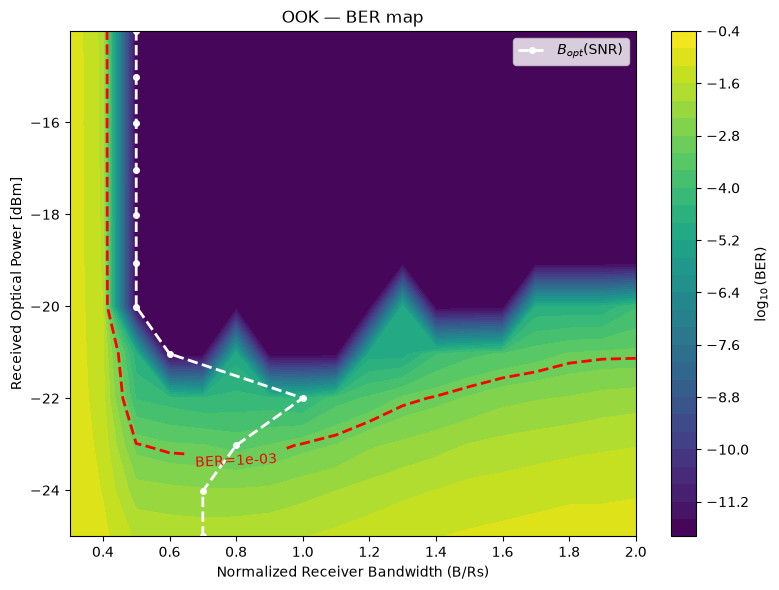

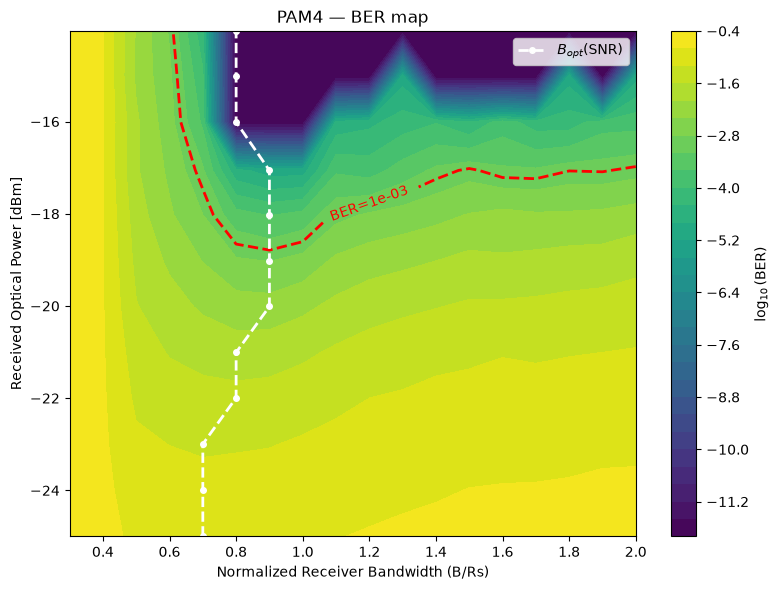

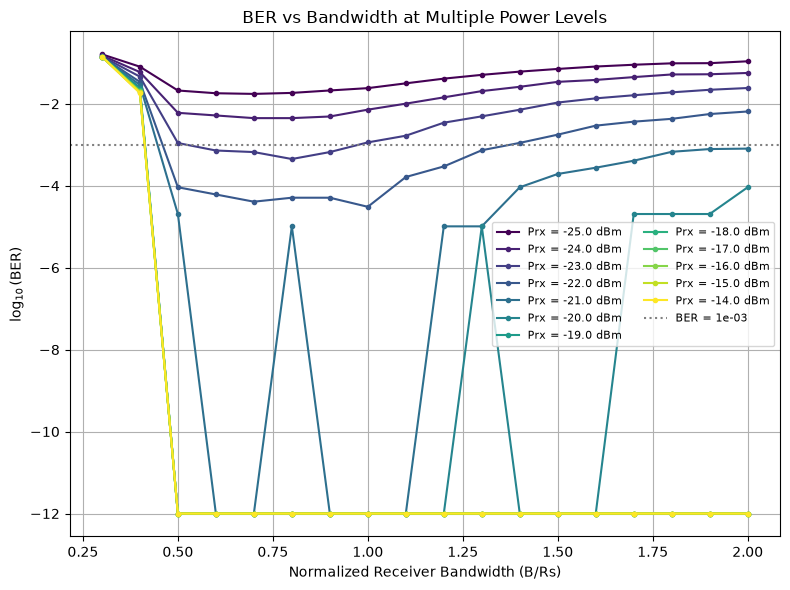

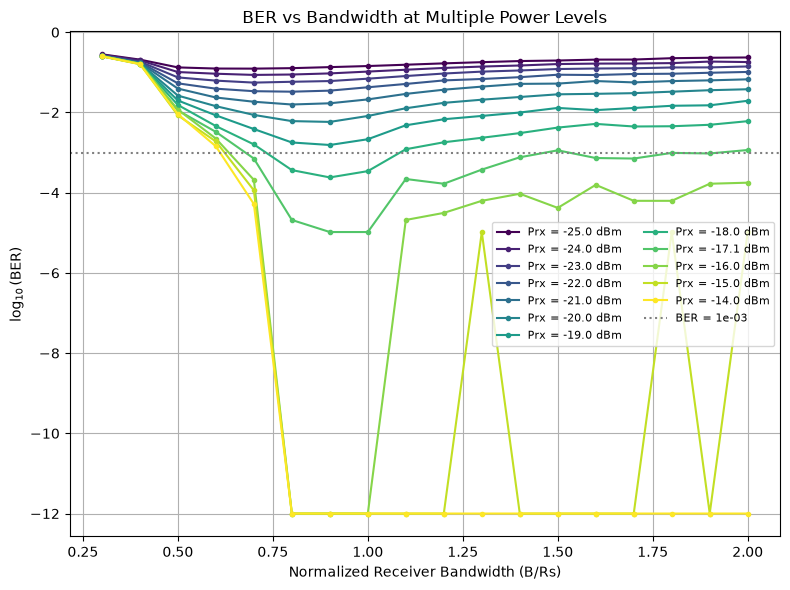

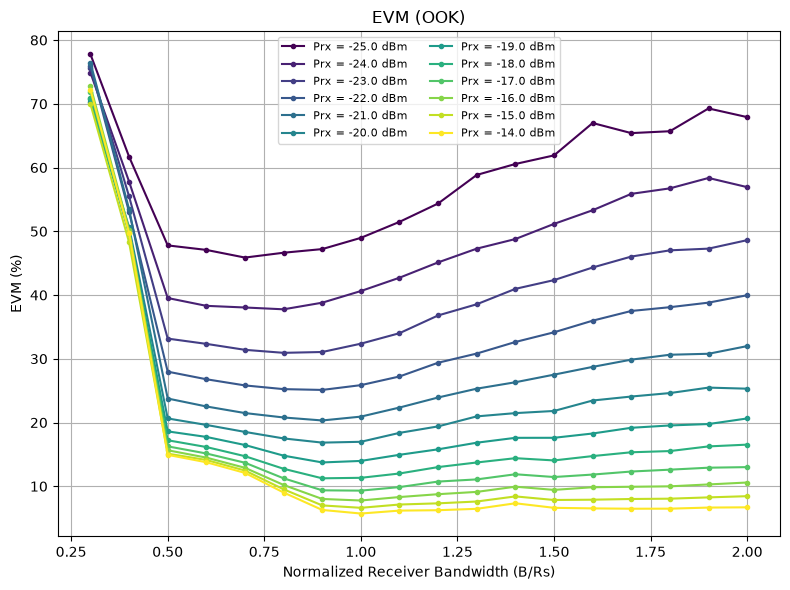

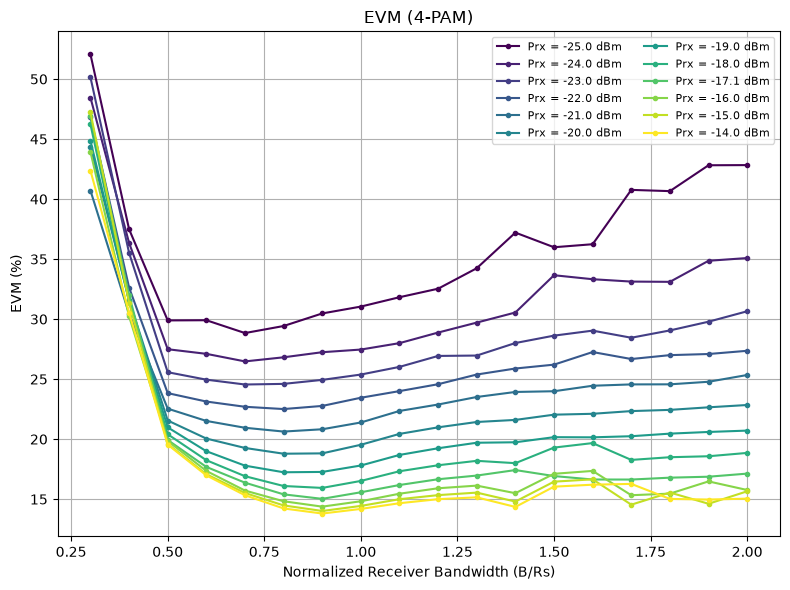

In [4]:
from imdd_lib import sweep_ber_vs_bw_and_power, plot_ber_contour_bw_power, plot_ber_vs_bandwidth_waterfall, plot_evm_vs_bandwidth_waterfall

bw_range_OOK    = np.linspace(0.3, 2.0, 18) * 10e9      # B/Rs = 0.3 .. 2.0
bw_range_4PAM    = np.linspace(0.3, 2.0, 18) * 5e9
power_range = np.arange(-20, -8, 1)                 # Pi_dBm -> Prx_dBm

res_ook  = sweep_ber_vs_bw_and_power(bw_range_OOK, power_range, M=2, Rs=10e9, fiber_L=10,
save_path  = "results/tables/ber_vs_rx_bw.xlsx",
sheet_name = "sweep43_OOK")
res_pam4 = sweep_ber_vs_bw_and_power(bw_range_4PAM, power_range, M=4, Rs=5e9, fiber_L=10,
save_path  = "results/tables/ber_vs_rx_bw.xlsx",
sheet_name = "sweep43_4PAM")

plot_ber_contour_bw_power(res_ook,  title='OOK — BER map',  target_BER=1e-3)
plot_ber_contour_bw_power(res_pam4, title='PAM4 — BER map', target_BER=1e-3)
plot_ber_vs_bandwidth_waterfall(res_ook, target_BER=1e-3)
plot_ber_vs_bandwidth_waterfall(res_pam4, target_BER=1e-3)
plot_evm_vs_bandwidth_waterfall(res_ook, title='EVM (OOK)')
plot_evm_vs_bandwidth_waterfall(res_pam4, title='EVM (4-PAM)')

**OOK Test**

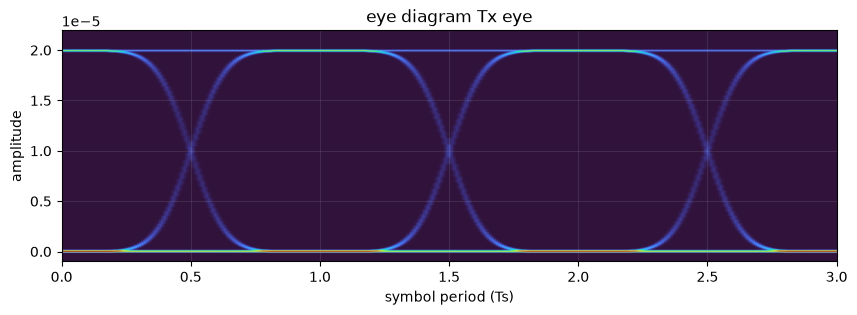

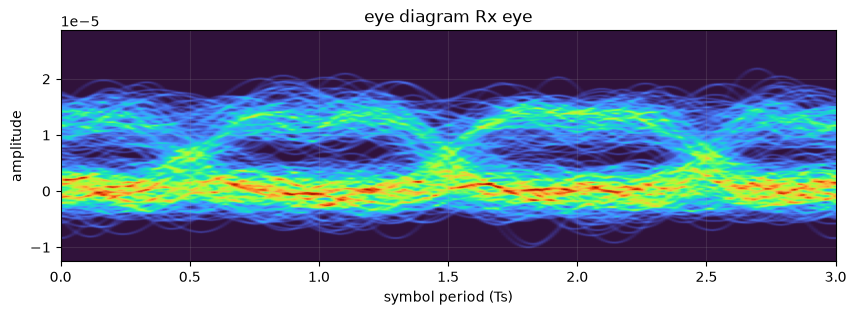

log10(BER) = -2.211


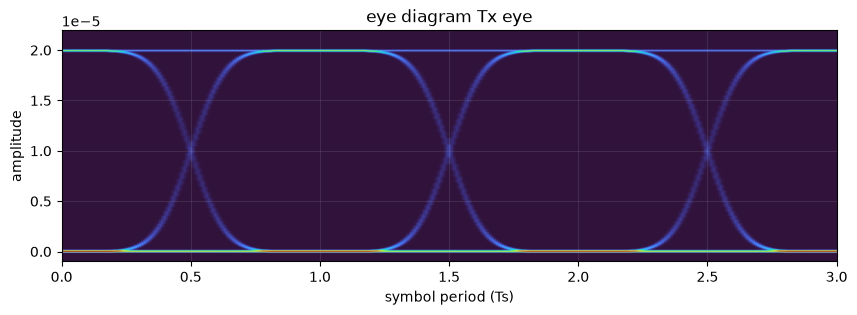

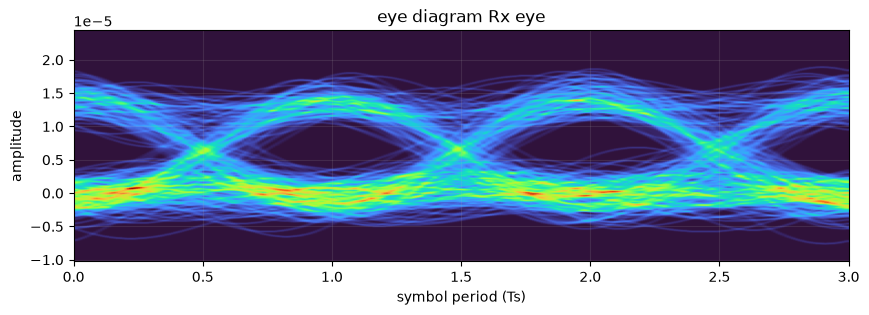

log10(BER) = -3.949


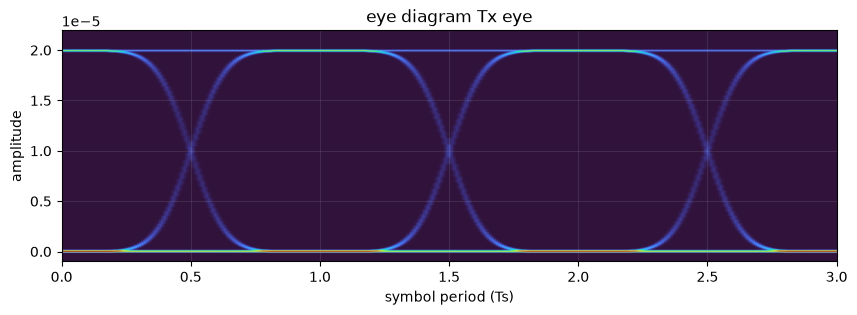

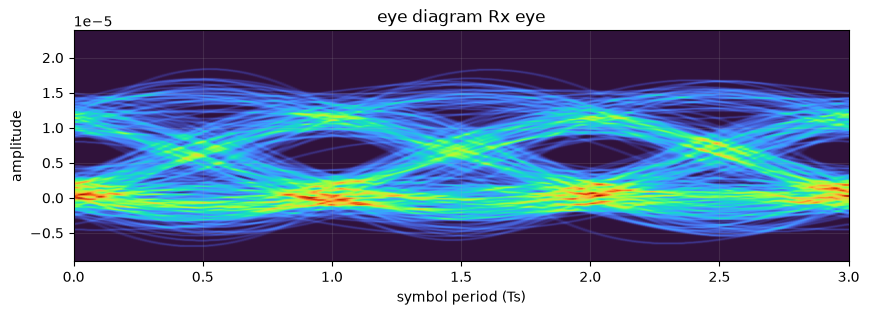

log10(BER) = -3.787


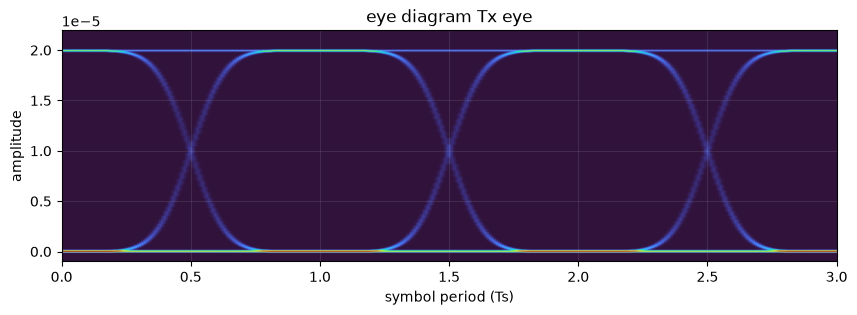

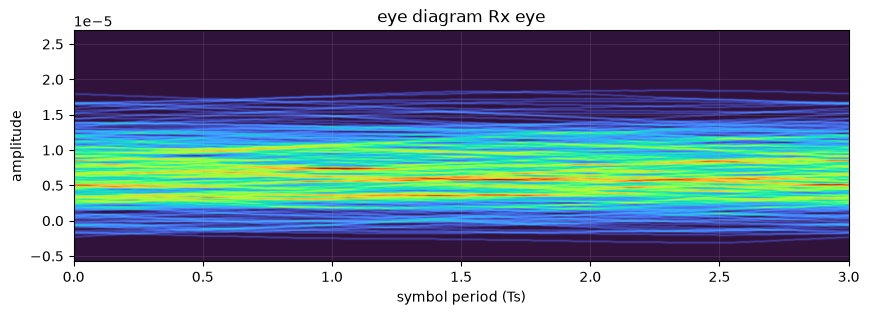

log10(BER) = -0.496


In [40]:
Rs_test = 10e9
bw_test = 2 * Rs_test

res4 = run_link(
    Pi_dBm=-17,
    M=2,
    Rs= Rs_test,
    rx_bandwidth= bw_test,
    fiber_L=10,
)
plot_eye_diagrams(res4, discard=50)
print(f"log10(BER) = {np.log10(max(res4['BER'], 1e-12)):.3f}")

bw_test = 1 * Rs_test

res4 = run_link(
    Pi_dBm=-17,
    M=2,
    Rs= Rs_test,
    rx_bandwidth= bw_test,
    fiber_L=10,
)
plot_eye_diagrams(res4, discard=50)
print(f"log10(BER) = {np.log10(max(res4['BER'], 1e-12)):.3f}")

bw_test = 0.5 * Rs_test

res4 = run_link(
    Pi_dBm=-17,
    M=2,
    Rs= Rs_test,
    rx_bandwidth= bw_test,
    fiber_L=10,
)
plot_eye_diagrams(res4, discard=50)
print(f"log10(BER) = {np.log10(max(res4['BER'], 1e-12)):.3f}")

bw_test = 0.1 * Rs_test

res4 = run_link(
    Pi_dBm=-17,
    M=2,
    Rs= Rs_test,
    rx_bandwidth= bw_test,
    fiber_L=0,
)
plot_eye_diagrams(res4, discard=50)
print(f"log10(BER) = {np.log10(max(res4['BER'], 1e-12)):.3f}")

**4PAM Test**

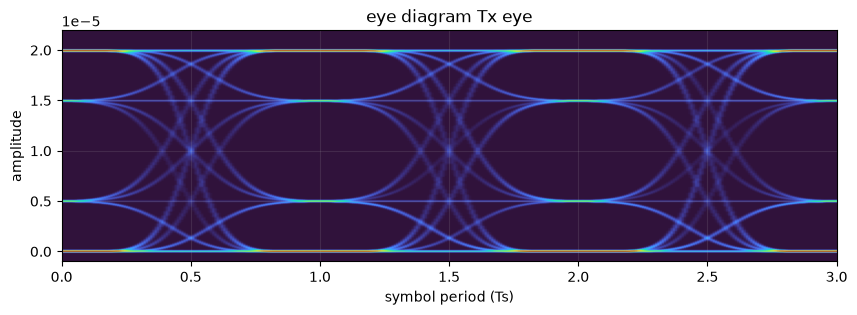

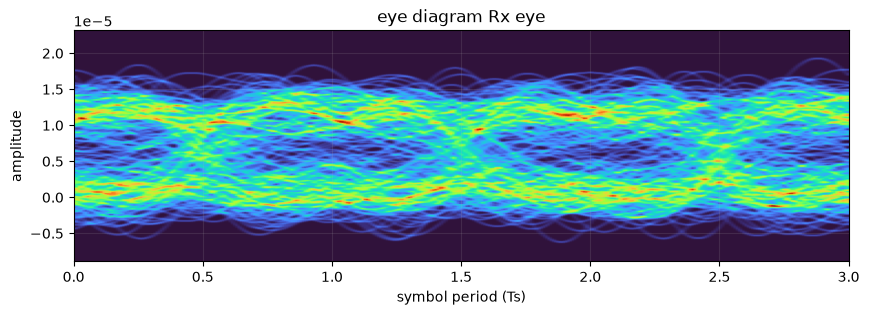

log10(BER) = -0.985


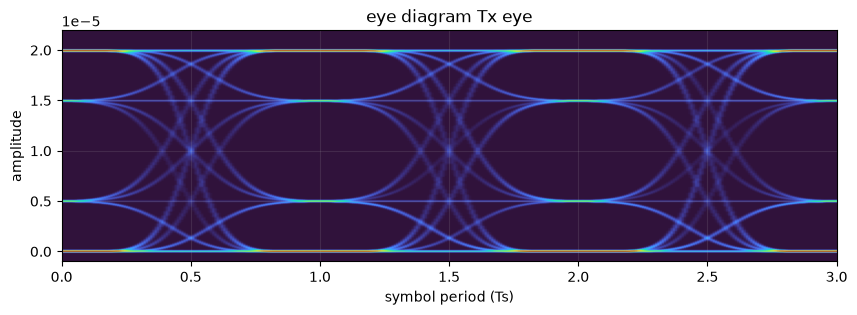

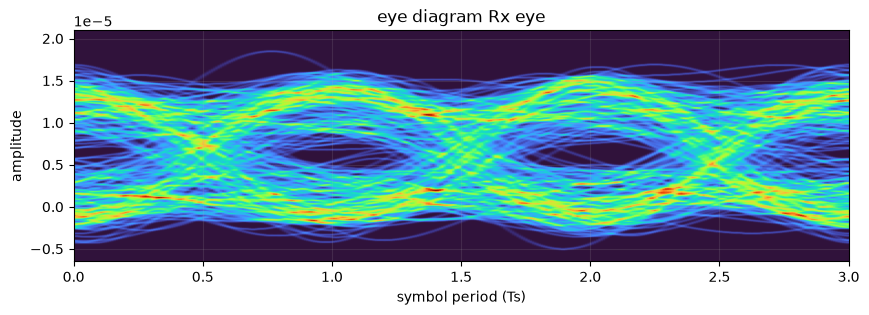

log10(BER) = -1.388


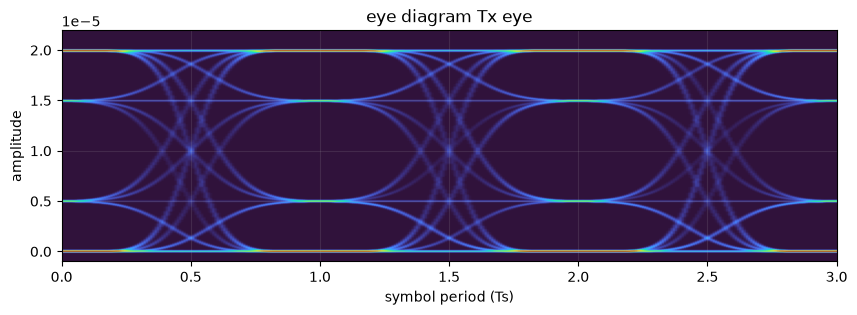

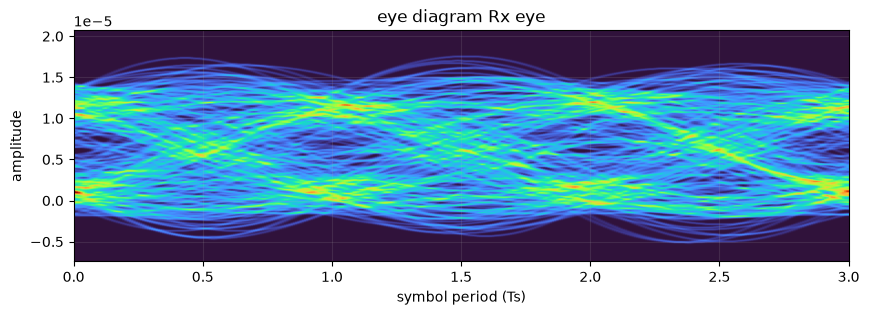

log10(BER) = -1.281


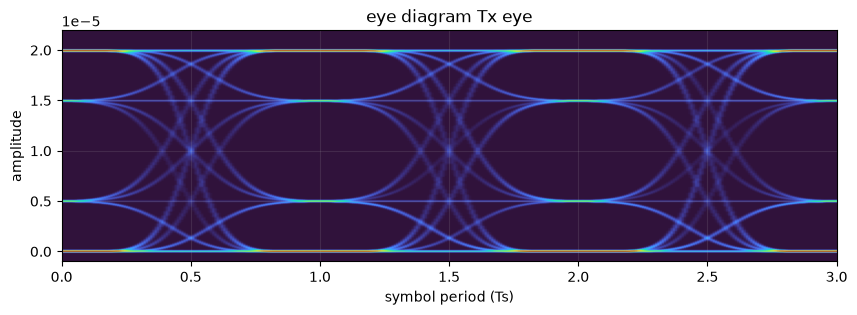

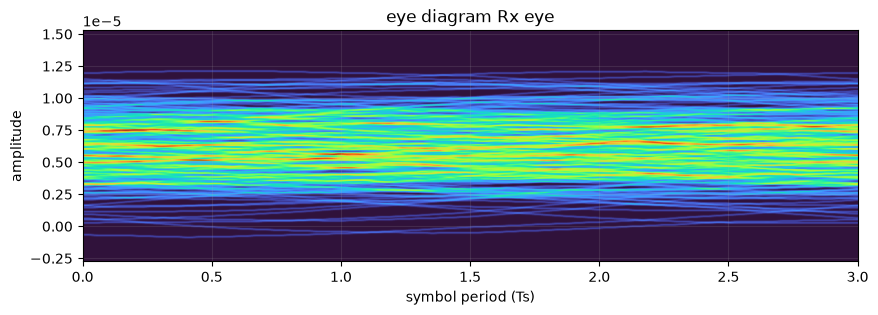

log10(BER) = -0.396


In [41]:
Rs_test = 5e9

bw_test = 2 * Rs_test

res4 = run_link(
    Pi_dBm=-17,
    M=4,
    Rs= Rs_test,
    rx_bandwidth= bw_test,
    fiber_L=10,
)
plot_eye_diagrams(res4, discard=50)
print(f"log10(BER) = {np.log10(max(res4['BER'], 1e-12)):.3f}")

bw_test = 1 * Rs_test

res4 = run_link(
    Pi_dBm=-17,
    M=4,
    Rs= Rs_test,
    rx_bandwidth= bw_test,
    fiber_L=10,
)
plot_eye_diagrams(res4, discard=50)
print(f"log10(BER) = {np.log10(max(res4['BER'], 1e-12)):.3f}")

bw_test = 0.5 * Rs_test

res4 = run_link(
    Pi_dBm=-17,
    M=4,
    Rs= Rs_test,
    rx_bandwidth= bw_test,
    fiber_L=10,
)
plot_eye_diagrams(res4, discard=50)
print(f"log10(BER) = {np.log10(max(res4['BER'], 1e-12)):.3f}")

bw_test = 0.1 * Rs_test

res4 = run_link(
    Pi_dBm=-17,
    M=4,
    Rs= Rs_test,
    rx_bandwidth= bw_test,
    fiber_L=10,
)
plot_eye_diagrams(res4, discard=50)
print(f"log10(BER) = {np.log10(max(res4['BER'], 1e-12)):.3f}")

---
## 5. Sweep 3 — BER vs Fiber Dispersion

**Fixed:** transmit power, fiber length, receiver bandwidth  
**Swept:** dispersion coefficient `D` [ps/nm/km]  
**Goal:** quantify dispersion tolerance difference between OOK and PAM4

**5.1 10Gb/s**

In [ ]:
dispersion_range = np.arange(0, 600, 20)  # [ps/nm/km]
Pi_disp          = -20  # [dBm]

bit_rate = 10e9        # b/s
Rs_OOK_51  = bit_rate     # symbol rate [Hz]
Rs_4PAM_51 = bit_rate/2

RX_BW_OOK_51 = Rs_OOK_51         # matched-filter bandwidth (B = Rs)
RX_BW_4PAM_51 = Rs_4PAM_51

# OOK
sweep4_ook = sweep_param(
    param_name   = 'fiber_D',
    param_range  = dispersion_range,
    fixed_params = {
        'Pi_dBm':       Pi_disp,
        'M':            2,
        'Rs':           Rs_OOK_51,
        'SpS':          SpS,
        'fiber_L':      FIBER_L,
        'fiber_alpha':  FIBER_ALPHA,
        'Fc':           Fc,
        'rx_bandwidth': RX_BW_OOK_51,
        'nBits':        nBits,
    },
    save_path  = "results/tables/ber_vs_d_10Gbs.xlsx",
    sheet_name = "sweep51_OOK"
)

# PAM4
sweep4_pam4 = sweep_param(
    param_name   = 'fiber_D',
    param_range  = dispersion_range,
    fixed_params = {
        'Pi_dBm':       Pi_disp,
        'M':            4,
        'Rs':           Rs_4PAM_51,
        'SpS':          SpS,
        'fiber_L':      FIBER_L,
        'fiber_alpha':  FIBER_ALPHA,
        'Fc':           Fc,
        'rx_bandwidth': RX_BW_4PAM_51,
        'nBits':        nBits,
    },
    save_path  = "results/tables/ber_vs_d_10Gbs.xlsx",
    sheet_name = "sweep51_4PAM"
)

In [ ]:
plot_ber_vs_dispersion(
    results_list = [sweep4_ook, sweep4_pam4],
    labels       = ['OOK', '4PAM'],
    title        = f'BER vs Dispersion  |  Pi={Pi_disp} dBm, L={FIBER_L} km, Rb = {bit_rate/1e9} Gb/s',
)

**5.2 20Gb/s**

In [ ]:
dispersion_range = np.arange(0, 150, 10)  # [ps/nm/km]
Pi_disp          = -20  # [dBm]

bit_rate = 20e9        # Gb/s
Rs_OOK_52  = bit_rate     # symbol rate [Hz]
Rs_4PAM_52 = bit_rate/2

RX_BW_OOK_52 = Rs_OOK_52       # matched-filter bandwidth (B = Rs)
RX_BW_4PAM_52 = Rs_4PAM_52

# OOK
sweep52_ook = sweep_param(
    param_name   = 'fiber_D',
    param_range  = dispersion_range,
    fixed_params = {
        'Pi_dBm':       Pi_disp,
        'M':            2,
        'Rs':           Rs_OOK_52,
        'SpS':          SpS,
        'fiber_L':      FIBER_L,
        'fiber_alpha':  FIBER_ALPHA,
        'Fc':           Fc,
        'rx_bandwidth': RX_BW_OOK_52,
        'nBits':        nBits,
    },
    save_path  = "results/tables/ber_vs_d_20Gbs.xlsx",
    sheet_name = "sweep52_OOK"
)

# PAM4
sweep52_pam4 = sweep_param(
    param_name   = 'fiber_D',
    param_range  = dispersion_range,
    fixed_params = {
        'Pi_dBm':       Pi_disp,
        'M':            4,
        'Rs':           Rs_4PAM_52,
        'SpS':          SpS,
        'fiber_L':      FIBER_L,
        'fiber_alpha':  FIBER_ALPHA,
        'Fc':           Fc,
        'rx_bandwidth': RX_BW_4PAM_52,
        'nBits':        nBits,
    },
    save_path  = "results/tables/ber_vs_d_20Gbs.xlsx",
    sheet_name = "sweep52_4PAM"
)

In [ ]:
plot_ber_vs_dispersion(
    results_list = [sweep52_ook, sweep52_pam4],
    labels       = ['OOK', '4PAM'],
    title        = f'BER vs Dispersion  |  Pi={Pi_disp} dBm, L={FIBER_L} km, Rb = {bit_rate/1e9} Gb/s',
)

**5.3 40Gb/s**

In [ ]:
dispersion_range = np.arange(0, 50, 2)  # [ps/nm/km]
Pi_disp          = -20  # [dBm]

bit_rate = 40e9        # Gb/s
Rs_OOK_53  = bit_rate     # symbol rate [Hz]
Rs_4PAM_53 = bit_rate/2

RX_BW_OOK_53 = Rs_OOK_53       # matched-filter bandwidth (B = Rs)
RX_BW_4PAM_53 = Rs_4PAM_53

# OOK
sweep52_ook = sweep_param(
    param_name   = 'fiber_D',
    param_range  = dispersion_range,
    fixed_params = {
        'Pi_dBm':       Pi_disp,
        'M':            2,
        'Rs':           Rs_OOK_53,
        'SpS':          SpS,
        'fiber_L':      FIBER_L,
        'fiber_alpha':  FIBER_ALPHA,
        'Fc':           Fc,
        'rx_bandwidth': RX_BW_OOK_53,
        'nBits':        nBits,
    },
    save_path  = "results/tables/ber_vs_d.xlsx",
    sheet_name = "sweep53_40Gbs_OOK"
)

# PAM4
sweep52_pam4 = sweep_param(
    param_name   = 'fiber_D',
    param_range  = dispersion_range,
    fixed_params = {
        'Pi_dBm':       Pi_disp,
        'M':            4,
        'Rs':           Rs_4PAM_53,
        'SpS':          SpS,
        'fiber_L':      FIBER_L,
        'fiber_alpha':  FIBER_ALPHA,
        'Fc':           Fc,
        'rx_bandwidth': RX_BW_4PAM_53,
        'nBits':        nBits,
    },
    save_path  = "results/tables/ber_vs_d.xlsx",
    sheet_name = "sweep53_40Gbs_4PAM"
)

plot_ber_vs_dispersion(
    results_list = [sweep52_ook, sweep52_pam4],
    labels       = ['OOK', '4PAM'],
    title        = f'BER vs Dispersion  |  Pi={Pi_disp} dBm, L={FIBER_L} km, Rb = {bit_rate/1e9} Gb/s',
)

In [ ]:
from imdd_lib import sweep_dlimit_vs_length_and_rate, plot_dlimit_waterfall

result = sweep_dlimit_vs_length_and_rate(
    length_range=np.linspace(10, 80, 15),
    rate_range=np.linspace(20e9, 80e9, 7),
    M=2,
    save_path  = "results/tables/D_vs_L_and_sybrate.xlsx",
    sheet_name = "sweep54_OOK"
)
plot_dlimit_waterfall(result, x_axis='length', rate_unit='Gbps', title='Dispersion Tolerance of OOK vs Rate at Multiple Lengths')

result = sweep_dlimit_vs_length_and_rate(
    length_range=np.linspace(10, 80, 15),
    rate_range=np.linspace(10e9, 40e9, 7),
    M=4,
    save_path  = "results/tables/D_vs_L_and_sybrate.xlsx",
    sheet_name = "sweep54_4PAM"
)
plot_dlimit_waterfall(result, x_axis='length', rate_unit='Gbps', title='Dispersion Tolerance of 4PAM vs Rate at Multiple Lengths')

---
## 6. Sweep 4 — BER vs Fiber Length

**Fixed:** transmit power, receiver bandwidth
**Swept:** fiber length `L`
**Goal:** determine the maximum reach for each modulation at BER = 10⁻³

**6.1:**

In [ ]:
length_range = np.arange(0, 60, 5)   # [km]
Pi_len       = -10  # [dBm] — fixed laser input power for this sweep

bit_rate = 10e9        # Gb/s
Rs_OOK_61  = bit_rate     # symbol rate [Hz]
Rs_4PAM_61 = bit_rate/2

RX_BW_OOK_61 = Rs_OOK_61       # matched-filter bandwidth (B = Rs)
RX_BW_4PAM_61 = Rs_4PAM_61

FIBER_D_61 = 0
nBits_61 = 1000000

# OOK
sweep3_ook = sweep_param(
    param_name   = 'fiber_L',
    param_range  = length_range,
    fixed_params = {
        'Pi_dBm':       Pi_len,
        'M':            2,
        'Rs':           Rs_OOK_61,
        'SpS':          SpS,
        'fiber_alpha':  FIBER_ALPHA,
        'fiber_D':      FIBER_D_61,
        'Fc':           Fc,
        'rx_bandwidth': RX_BW_OOK_61,
        'nBits':        nBits_61,
    }
)

# PAM4
sweep3_pam4 = sweep_param(
    param_name   = 'fiber_L',
    param_range  = length_range,
    fixed_params = {
        'Pi_dBm':       Pi_len,
        'M':            4,
        'Rs':           Rs_4PAM_61,
        'SpS':          SpS,
        'fiber_alpha':  FIBER_ALPHA,
        'fiber_D':      FIBER_D_61,
        'Fc':           Fc,
        'rx_bandwidth': RX_BW_4PAM_61,
        'nBits':        nBits_61,
    }
)

plot_ber_vs_length(
    results_list = [sweep3_ook, sweep3_pam4],
    labels       = ['OOK', '4PAM'],
    title        = f'BER vs Fiber Length OOK  |  Pi={Pi_len} dBm, bit rate = {bit_rate/1e9} Gb/s, D = {FIBER_D_61} ps/nm/km, B/Rs = 1',
)

**6.2:**

In [ ]:
length_range = np.arange(0, 60, 5)   # [km]
Pi_len       = -10  # [dBm] — fixed transmit power for this sweep

bit_rate = 10e9        # Gb/s
Rs_OOK_61  = bit_rate     # symbol rate [Hz]
Rs_4PAM_61 = bit_rate/2

RX_BW_OOK_61 = Rs_OOK_61       # matched-filter bandwidth (B = Rs)
RX_BW_4PAM_61 = Rs_4PAM_61

nBits_61 = 1000000
FIBER_D_62 = 16

# OOK
sweep3_ook = sweep_param(
    param_name   = 'fiber_L',
    param_range  = length_range,
    fixed_params = {
        'Pi_dBm':       Pi_len,
        'M':            2,
        'Rs':           Rs_OOK_61,
        'SpS':          SpS,
        'fiber_alpha':  FIBER_ALPHA,
        'fiber_D':      FIBER_D_62,
        'Fc':           Fc,
        'rx_bandwidth': RX_BW_OOK_61,
        'nBits':        nBits_61,
    }
)

# PAM4
sweep3_pam4 = sweep_param(
    param_name   = 'fiber_L',
    param_range  = length_range,
    fixed_params = {
        'Pi_dBm':       Pi_len,
        'M':            4,
        'Rs':           Rs_4PAM_61,
        'SpS':          SpS,
        'fiber_alpha':  FIBER_ALPHA,
        'fiber_D':      FIBER_D_62,
        'Fc':           Fc,
        'rx_bandwidth': RX_BW_4PAM_61,
        'nBits':        nBits_61,
    }
)

plot_ber_vs_length(
    results_list = [sweep3_ook, sweep3_pam4],
    labels       = ['OOK', '4PAM'],
    title        = f'BER vs Fiber Length 4PAM  |  Pi={Pi_len} dBm, bit rate = {bit_rate/1e9} Gb/s, D = {FIBER_D_62} ps/nm/km, B/Rs = 1',
)

**6.3**

In [ ]:
from imdd_lib import sweep_lmax_vs_rate_and_power, plot_lmax_waterfall, plot_lmax_contour
import numpy as np

result = sweep_lmax_vs_rate_and_power(
    Rb_range_Gbps=np.linspace(10, 100, 10),
    Pi_range_dBm=np.linspace(-14, 0, 8),
    M=2,
    fiber_D=18,
    target_BER=1e-3,
    save_path='results/tables/lmax_results.xlsx',
)

plot_lmax_waterfall(result, x_axis='rate')
plot_lmax_contour(result)

In [ ]:
result2 = sweep_lmax_vs_rate_and_power(
    Rb_range_Gbps=np.linspace(10, 100, 10),
    Pi_range_dBm=np.linspace(-14, 0, 8),
    M=4,
    fiber_D=18,
    target_BER=1e-3,
    save_path='results/tables/lmax_results2.xlsx',
)

plot_lmax_waterfall(result2, x_axis='rate')
plot_lmax_contour(result2)